In [1]:
!nvidia-smi

Tue Jan 27 09:34:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [5]:
# Install dependencies
!pip install -q rfdetr supervision roboflow

#### Download example data

In [4]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


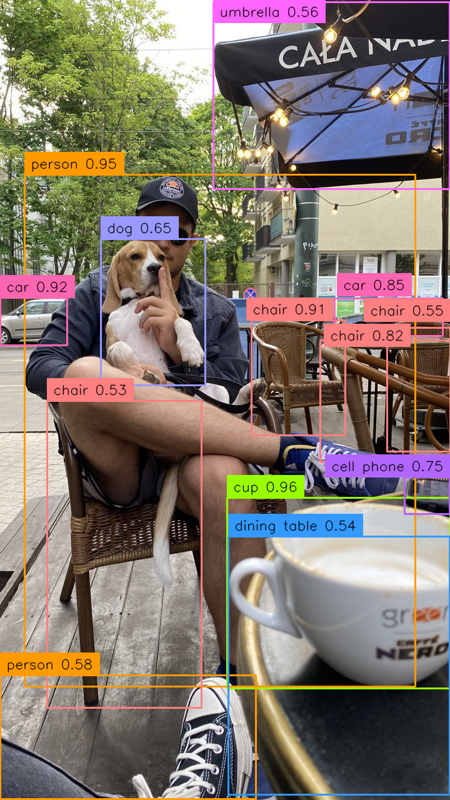

In [9]:
# Running inference on pre-trained rfdetr model using examples data

import numpy as np
import supervision as sv
from PIL import Image

from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES

image = Image.open("/content/dog-3.jpeg")

model = RFDETRMedium(resolution=640)
model.optimize_for_inference()

detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image.thumbnail((800, 800))
annotated_image

## Performing custom training

### Download Dataset from Roboflow Universe

RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

In [10]:
# Downloading dataset

from roboflow import download_dataset

dataset = download_dataset("https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/13", "coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to basketball-player-detection-2-13 in coco:: 100%|██████████| 1406/1406 [00:01<00:00, 1037.03it/s]


In [12]:
# Trainning
from rfdetr import RFDETRNano
model = RFDETRNano()

model.train(dataset_dir=dataset.location, epochs=20, batch_size=4, grad_accum_steps=4)

rf-detr-nano.pth: 100%|██████████| 349M/349M [00:09<00:00, 38.8MiB/s]


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=6, grad_accum_steps=2, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=8, weight_decay=0.0001, epochs=20, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an erro

Epoch: [0]  [ 0/65]  eta: 0:05:02  lr: 0.000100  class_error: 93.72  loss: 7.6154 (7.6154)  loss_ce: 1.1861 (1.1861)  loss_bbox: 0.3448 (0.3448)  loss_giou: 0.9660 (0.9660)  loss_ce_0: 1.1496 (1.1496)  loss_bbox_0: 0.3799 (0.3799)  loss_giou_0: 0.9820 (0.9820)  loss_ce_enc: 1.2267 (1.2267)  loss_bbox_enc: 0.3776 (0.3776)  loss_giou_enc: 1.0028 (1.0028)  loss_ce_unscaled: 1.1861 (1.1861)  class_error_unscaled: 93.7170 (93.7170)  loss_bbox_unscaled: 0.0690 (0.0690)  loss_giou_unscaled: 0.4830 (0.4830)  cardinality_error_unscaled: 3882.3750 (3882.3750)  loss_ce_0_unscaled: 1.1496 (1.1496)  loss_bbox_0_unscaled: 0.0760 (0.0760)  loss_giou_0_unscaled: 0.4910 (0.4910)  cardinality_error_0_unscaled: 3883.6250 (3883.6250)  loss_ce_enc_unscaled: 1.2267 (1.2267)  loss_bbox_enc_unscaled: 0.0755 (0.0755)  loss_giou_enc_unscaled: 0.5014 (0.5014)  cardinality_error_enc_unscaled: 3883.6250 (3883.6250)  time: 4.6563  data: 0.9760  max mem: 4958
Epoch: [0]  [10/65]  eta: 0:02:50  lr: 0.000100  class_er

Mean of empty slice
Mean of empty slice
Mean of empty slice


Test:  [ 0/24]  eta: 0:00:20  class_error: 7.10  loss: 4.4631 (4.4631)  loss_ce: 0.6133 (0.6133)  loss_bbox: 0.1392 (0.1392)  loss_giou: 0.7092 (0.7092)  loss_ce_0: 0.6484 (0.6484)  loss_bbox_0: 0.1469 (0.1469)  loss_giou_0: 0.6963 (0.6963)  loss_ce_enc: 0.6250 (0.6250)  loss_bbox_enc: 0.1577 (0.1577)  loss_giou_enc: 0.7272 (0.7272)  loss_ce_unscaled: 0.6133 (0.6133)  class_error_unscaled: 7.0968 (7.0968)  loss_bbox_unscaled: 0.0278 (0.0278)  loss_giou_unscaled: 0.3546 (0.3546)  cardinality_error_unscaled: 257.8750 (257.8750)  loss_ce_0_unscaled: 0.6484 (0.6484)  loss_bbox_0_unscaled: 0.0294 (0.0294)  loss_giou_0_unscaled: 0.3481 (0.3481)  cardinality_error_0_unscaled: 252.7500 (252.7500)  loss_ce_enc_unscaled: 0.6250 (0.6250)  loss_bbox_enc_unscaled: 0.0315 (0.0315)  loss_giou_enc_unscaled: 0.3636 (0.3636)  cardinality_error_enc_unscaled: 263.7500 (263.7500)  time: 0.8547  data: 0.3921  max mem: 7314
Test:  [10/24]  eta: 0:00:07  class_error: 4.67  loss: 4.3783 (4.3532)  loss_ce: 0.61

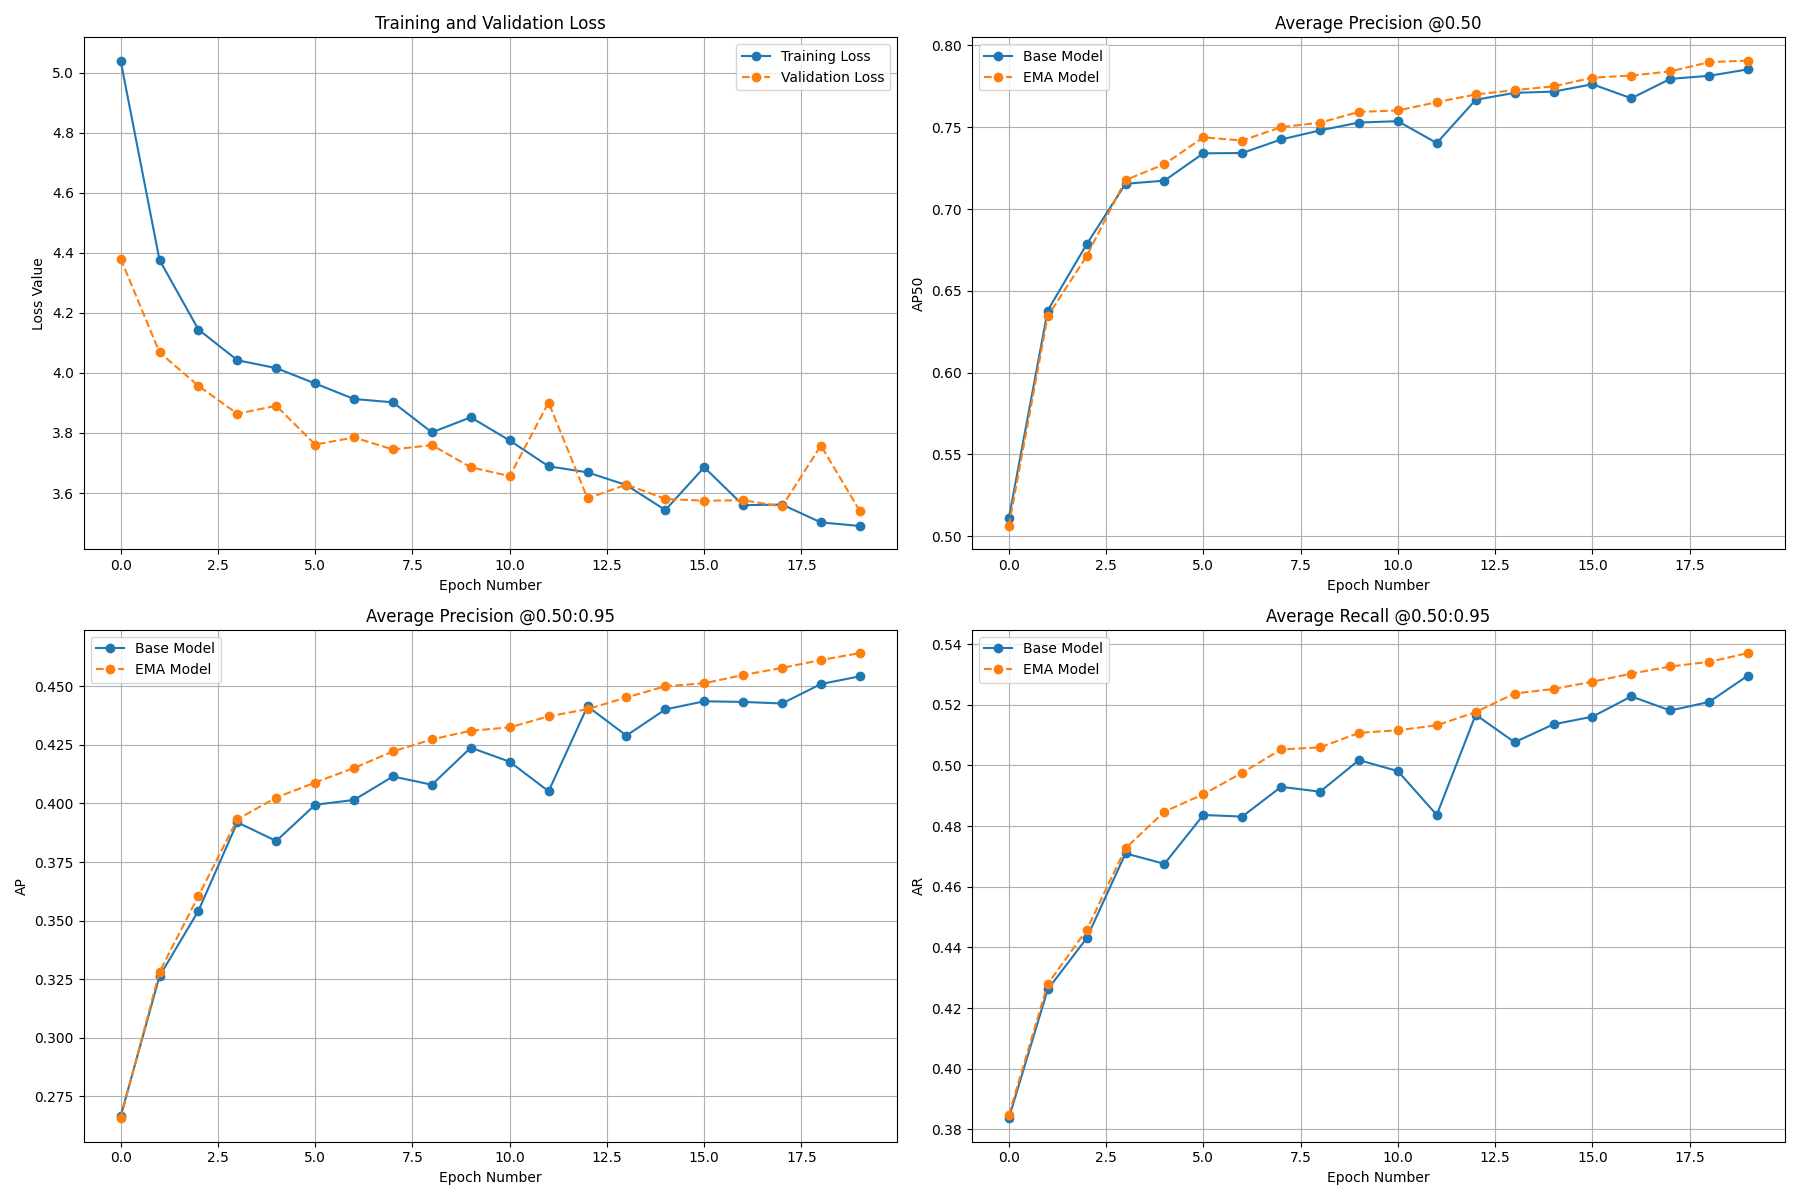

In [13]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

In [14]:
!ls -la /content/output

total 2247708
drwxr-xr-x 3 root root      4096 Jan 27 11:06 .
drwxr-xr-x 1 root root      4096 Jan 27 09:52 ..
-rw-r--r-- 1 root root 484664813 Jan 27 10:29 checkpoint0009.pth
-rw-r--r-- 1 root root 484664813 Jan 27 11:05 checkpoint0019.pth
-rw-r--r-- 1 root root 362610474 Jan 27 11:06 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 363841030 Jan 27 10:40 checkpoint_best_regular.pth
-rw-r--r-- 1 root root 120840095 Jan 27 11:06 checkpoint_best_total.pth
-rw-r--r-- 1 root root 484655501 Jan 27 11:05 checkpoint.pth
drwxr-xr-x 2 root root      4096 Jan 27 09:56 eval
-rw-r--r-- 1 root root      8752 Jan 27 11:06 events.out.tfevents.1769507560.c3e9c814b220.234.0
-rw-r--r-- 1 root root    124344 Jan 27 11:06 log.txt
-rw-r--r-- 1 root root    184592 Jan 27 11:06 metrics_plot.png
-rw-r--r-- 1 root root      1854 Jan 27 11:06 results.json


### Deploy a Trained RF-DETR Model

In [16]:
model.deploy_to_roboflow(
  workspace="roboflow-jvuqo",
  project_id="basketball-player-detection-2",
  version=13,
  api_key=os.environ["ROBOFLOW_API_KEY"]
)

loading Roboflow workspace...
loading Roboflow project...
An error occured when getting the model upload URL: 404 Client Error: Not Found for url: https://api.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/13/uploadModel?api_key=Wxd33dwwWH4t4Vwsd0g3&modelType=rfdetr-nano&nocache=true


In [17]:
# Evaluate Fine-tuned RF-DETR Model

import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [18]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 133.05 MB | Reserved: 7852.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 133.05 MB | Reserved: 262.00 MB


In [19]:
model = RFDETRNano(pretrain_weights="/content/output/checkpoint_best_total.pth")
model.optimize_for_inference()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
torch.as_tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, thi

In [20]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [21]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 169/169 [00:10<00:00, 15.48it/s]


In [22]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.483
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.806
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.495
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.242
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.708
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.822


#### Run Inference with Fine-tuned RF-DETR Model

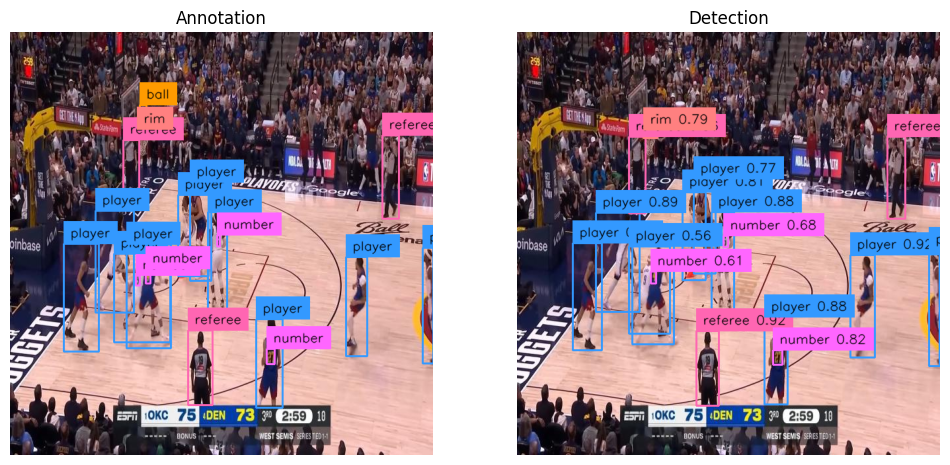

In [23]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])